<a href="https://colab.research.google.com/github/Priyanshi07-ai/supervised_fashion_cluster/blob/main/supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROJECT NAME - FASHION IMAGE CLUSTERING

CONTRIBUTION - INDIVIDUAL NAME - PRIYANSHI BHANDARI

github = https://github.com/Priyanshi07-ai

SUMMARY

Project Summary: Fashion Image Clustering using CNN and K-Means

This project focuses on grouping fashion images using Convolutional Neural Networks (CNN) and K-Means clustering. The dataset contains grayscale images of clothing items, with each image represented by pixel values. First, the data is preprocessed by normalizing the pixel values to a range of 0 to 1 and reshaping them into a 28×28×1 format suitable for CNN input.

Next, a CNN model is built and trained with labeled data. The model includes convolutional layers for feature extraction, pooling layers for reducing dimensions, and dense layers for classification. Instead of using the final classification output, features are extracted from the second to last layer of the CNN. These features capture important patterns like edges, shapes, and textures learned from the images.

The extracted feature vectors are then used as input for the K-Means clustering algorithm. This algorithm groups similar images based on the closeness of their features. Since K-Means is an unsupervised learning method, it does not use labels during clustering. To visualize the results, Principal Component Analysis (PCA) reduces the high-dimensional feature space to two dimensions. A scatter plot shows how the images are grouped into clusters.

The results indicate that similar fashion items are often grouped together, although some overlap occurs due to similarities between certain classes. This project demonstrates that combining supervised feature extraction with unsupervised clustering can effectively analyze and group image data.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.utils import to_categorical

LOAD AND WORK DATASET

In [ ]:
train_dir = pd.read_csv("fashion-mnist_train.csv")

#checking isnull
print(train_dir.isnull().sum())

# removing null values and changing to numeric
train_dir = train_dir.apply(pd.to_numeric, errors='coerce')
train_dir = train_dir.dropna()
print(train_dir.isnull().sum())

uv = pd.unique(train_dir['label'])
print(uv)

# print(train_dir.head())

label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    1
pixel781    1
pixel782    1
pixel783    1
pixel784    1
Length: 785, dtype: int64
label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 785, dtype: int64
[2 9 6 0 3 4 5 8 7 1]


In [ ]:
dfil = train_dir[train_dir['label'] == 9]
dfil = dfil.reset_index()
print(dfil.head())

labels = dfil.iloc[:, 1]
pixels = dfil.iloc[:, 2:]

# print(pixels.columns)
# print(labels)
# print(type(labels))

   index  label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1      9       0       0       0       0       0       0       0   
1     12      9       0       0       0       0       0       0       0   
2     16      9       0       0       0       0       0       0       0   
3     42      9       0       0       0       0       0       0       0   
4     56      9       0       0       0       0       0       0       0   

   pixel8  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
1       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
2       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
3       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
4       0  ...       0.0       0.0       0.0       0.0       0.0       0.0   

   pixel781  pixel782  pixel783  pixel784  
0       0.0       0.0       0.0     

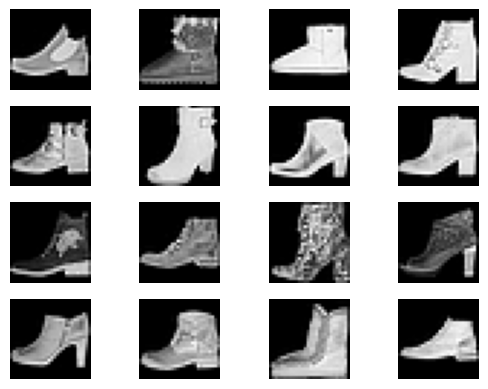

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
for i, idx in enumerate(dfil.index[:16]):
    plt.subplot(4,4,i+1)
    image = pixels.iloc[idx].values.reshape(28,28)
    plt.imshow(image, cmap='gray')
    plt.axis('off')

plt.show()

In [ ]:
# Separate label & pixels
labels = train_dir.iloc[:, 0]
pixels = train_dir.iloc[:, 1:]

# Normalize
pixels = pixels / 255.0

# Reshape to (28,28,1)
images = pixels.values.reshape(-1, 28, 28, 1)

In [ ]:
import numpy as np
from tensorflow.keras import layers
from tensorflow.keras.layers import Input

# Convert labels to categorical
y_cat = to_categorical(labels)

# Input layer
input_layer = Input(shape=(28,28,1))

# CNN
x = layers.Conv2D(32, (3,3), activation='relu')(input_layer)
x = layers.MaxPooling2D(2,2)(x)

x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D(2,2)(x)

x = layers.Flatten()(x)
feature_layer = layers.Dense(128, activation='relu')(x)

output = layers.Dense(10, activation='softmax')(feature_layer)

# Model
model = Model(inputs=input_layer, outputs=output)

# Compile (FIXED)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(images, y_cat, epochs=5, batch_size=128)

Epoch 1/5
381/381 ━━━━━━━━━━━━━━━━━━━━ 42s 106ms/step - accuracy: 0.7963 - loss: 0.5706
Epoch 2/5
381/381 ━━━━━━━━━━━━━━━━━━━━ 43s 111ms/step - accuracy: 0.8666 - loss: 0.3697
Epoch 3/5
381/381 ━━━━━━━━━━━━━━━━━━━━ 44s 116ms/step - accuracy: 0.8845 - loss: 0.3202
Epoch 4/5
381/381 ━━━━━━━━━━━━━━━━━━━━ 40s 105ms/step - accuracy: 0.8948 - loss: 0.2888
Epoch 5/5
381/381 ━━━━━━━━━━━━━━━━━━━━ 41s 107ms/step - accuracy: 0.9049 - loss: 0.2613


IMPORTANT FEATURES EXTRACTION

In [ ]:
from tensorflow.keras.models import Model

feature_model = Model(inputs=model.input,
                      outputs=model.layers[-2].output)

features = feature_model.predict(images)
features = np.nan_to_num(features)
print(np.isnan(features).sum())

1523/1523 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step
0


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(features)

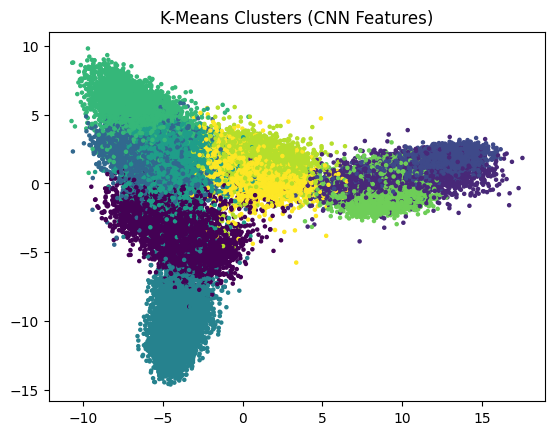

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(features)

plt.scatter(reduced[:,0], reduced[:,1], c=clusters, s=5)
plt.title("K-Means Clusters (CNN Features)")
plt.show()

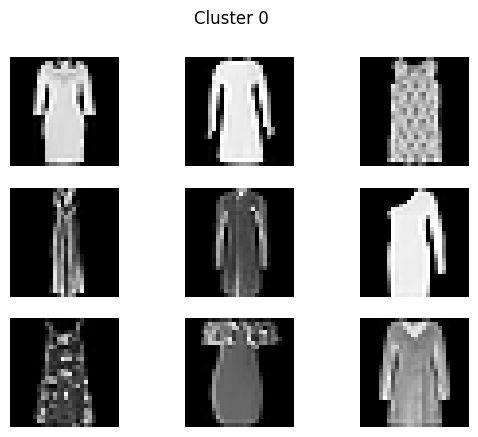

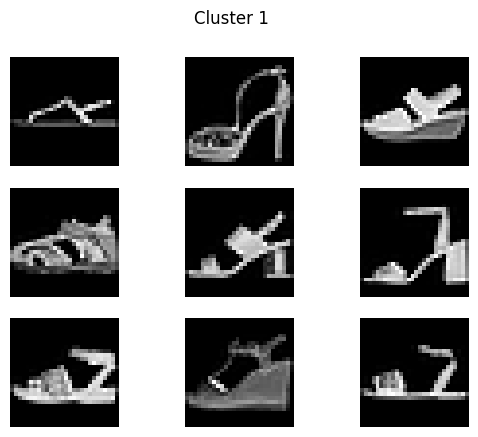

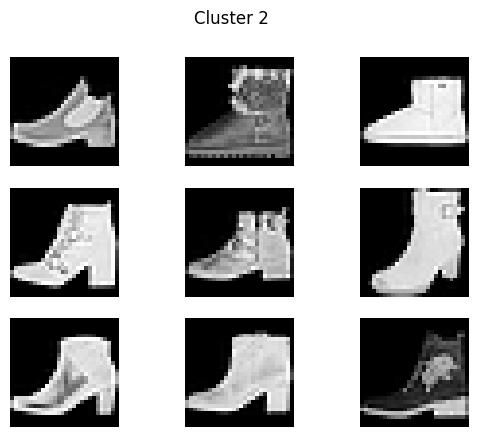

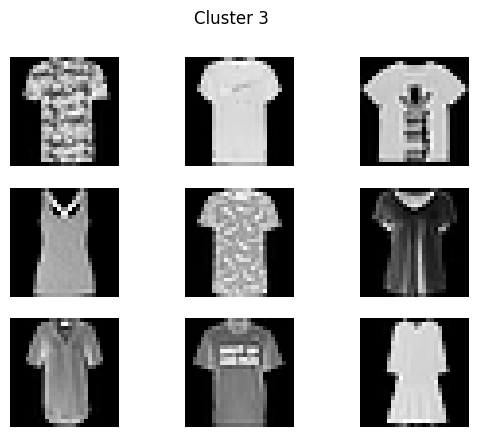

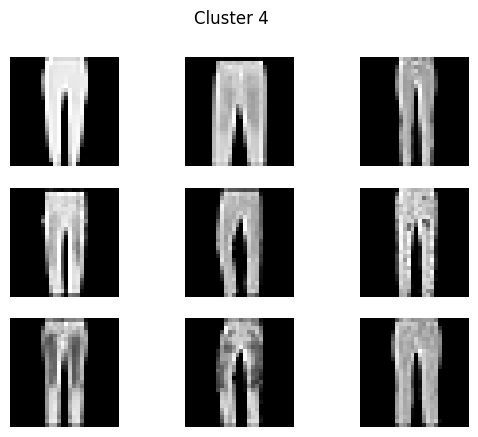

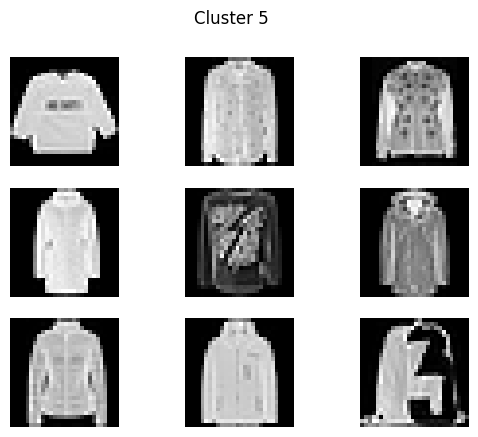

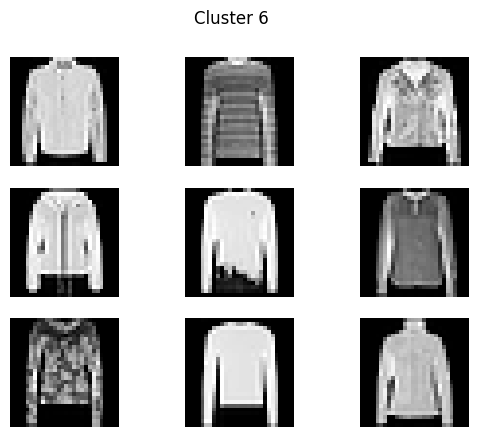

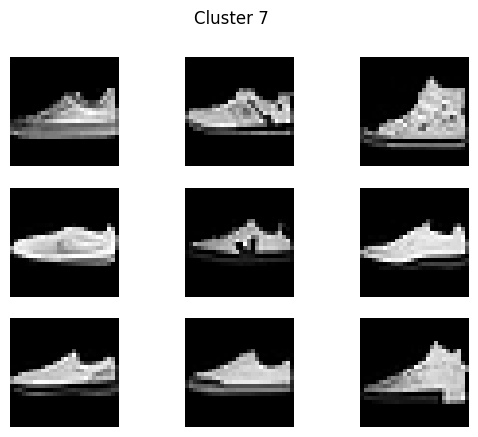

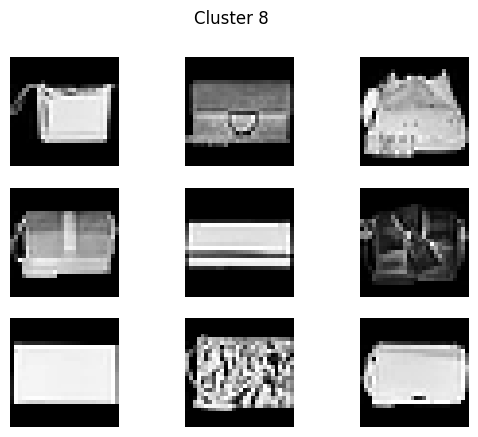

In [ ]:
  # show first 9 clusters
for c in range(9):
    idxs = np.where(clusters == c)[0][:9]

    for i, idx in enumerate(idxs):
        plt.subplot(3,3,i+1)
        plt.imshow(images[idx].reshape(28,28), cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Cluster {c}")
    plt.show()